# Week 6 - Function 7 ((35DP, 6D))

# Setup
Let's load all the imports in the top to avoid repeating and simplify the readability of each solution.

In [1]:
import numpy as np
import torch
import gpytorch

from sklearn.preprocessing import MinMaxScaler, QuantileTransformer
from sklearn.svm import SVC, SVR
from scipy.stats.qmc import LatinHypercube

from utils.plotting_utils import (
    plot_6D_blackbox_analysis,
    plot_output_outliers,
    plot_bar_diff,
    plot_nd_mean_uncertainty_slice,
    plot_nd_svm_analysis_slice,
    plot_nd_acquisition_comparison_slice
)

In [2]:
# ── GPyTorch utilities (shared across migrated notebooks) ──────────────────────

class MaternARD_ExactGP(gpytorch.models.ExactGP):
    def __init__(self, X, y, likelihood, n_dims, ls_prior=None):
        super().__init__(X, y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        ls_prior = ls_prior or gpytorch.priors.GammaPrior(3.0, 6.0)
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=2.5, ard_num_dims=n_dims,
                lengthscale_prior=ls_prior
            ),
            outputscale_prior=gpytorch.priors.GammaPrior(2.0, 0.15)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def fit_gpytorch_model(X_np, y_np, n_dims, noise=0.01, n_steps=300, lr=0.1, ls_prior=None):
    X_t = torch.tensor(X_np, dtype=torch.float64)
    y_t = torch.tensor(y_np, dtype=torch.float64)
    likelihood = gpytorch.likelihoods.GaussianLikelihood()
    likelihood.noise = noise
    model = MaternARD_ExactGP(X_t, y_t, likelihood, n_dims, ls_prior=ls_prior).double()
    likelihood = likelihood.double()
    model.train(); likelihood.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)
    losses = []
    for _ in range(n_steps):
        optimizer.zero_grad()
        loss = -mll(model(X_t), y_t)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
    model.eval(); likelihood.eval()
    return model, likelihood, losses


def gp_predict(model, likelihood, X_np):
    """Drop-in replacement for sklearn GP.predict(X, return_std=True)."""
    X_t = torch.tensor(X_np, dtype=torch.float64)
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pred = likelihood(model(X_t))
    return pred.mean.numpy(), pred.variance.sqrt().numpy()


def gp_converged_gpytorch(losses, min_loss_drop=0.1, max_final_loss=10.0):
    losses_arr = np.array(losses)
    loss_drop = losses_arr[0] - losses_arr[-1]
    converged = (not np.any(np.isnan(losses_arr))
                 and loss_drop >= min_loss_drop
                 and losses_arr[-1] < max_final_loss)
    return converged, {'loss_drop': loss_drop, 'final_loss': losses_arr[-1]}


# Plan
We now have ((35, 6)) — 35 data points, 6 dimensions, from `./data/week_6/function_7/`.

**Architecture**: Dual-GP ensemble (QT + log10) with SVM-constrained UCB.

**Key decisions** (carried forward):
- QuantileTransformer + log10 shift: outlier spikes (y ∈ [0.003, 1.61])
- SVM C=1 soft margin, median threshold, fail-safe at <5% coverage
- x3 identified as noise dim — LHS in 5D active subspace [x1,x2,x4,x5,x6]; x3 fixed at training mean

**Week 6 fixes:**
- **Noise detection recalibrated**: GPyTorch GammaPrior(3,6) regularises all ls < 2.0, so the old absolute threshold (100) never fires. Replaced with relative threshold: ls > mean + 2×std. Fallback to x3 (index 2) preserved — Week 5 sklearn ARD confirmed x3 is noise (ls=438,000).
- kappa=3.846 (budget-aware: week 6/13); 50K LHS candidates in 5D active space

**Steps:** Load data → Preprocessing → GP models (full 6D ARD, identifies x3 as noise) → SVM → Acquisition (5D active subspace) → Report

# 1. Load data

In [3]:
X_train_raw = np.load(r"./data/week_6/function_7/inputs.npy")
y_train_raw = np.load(r"./data/week_6/function_7/outputs.npy")
print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.2e}, {y_train_raw.max():.2e}]")

Shape: X=(35, 6), y=(35,)
X range: [0.0036, 0.9987]
y range: [2.70e-03, 2.53e+00]


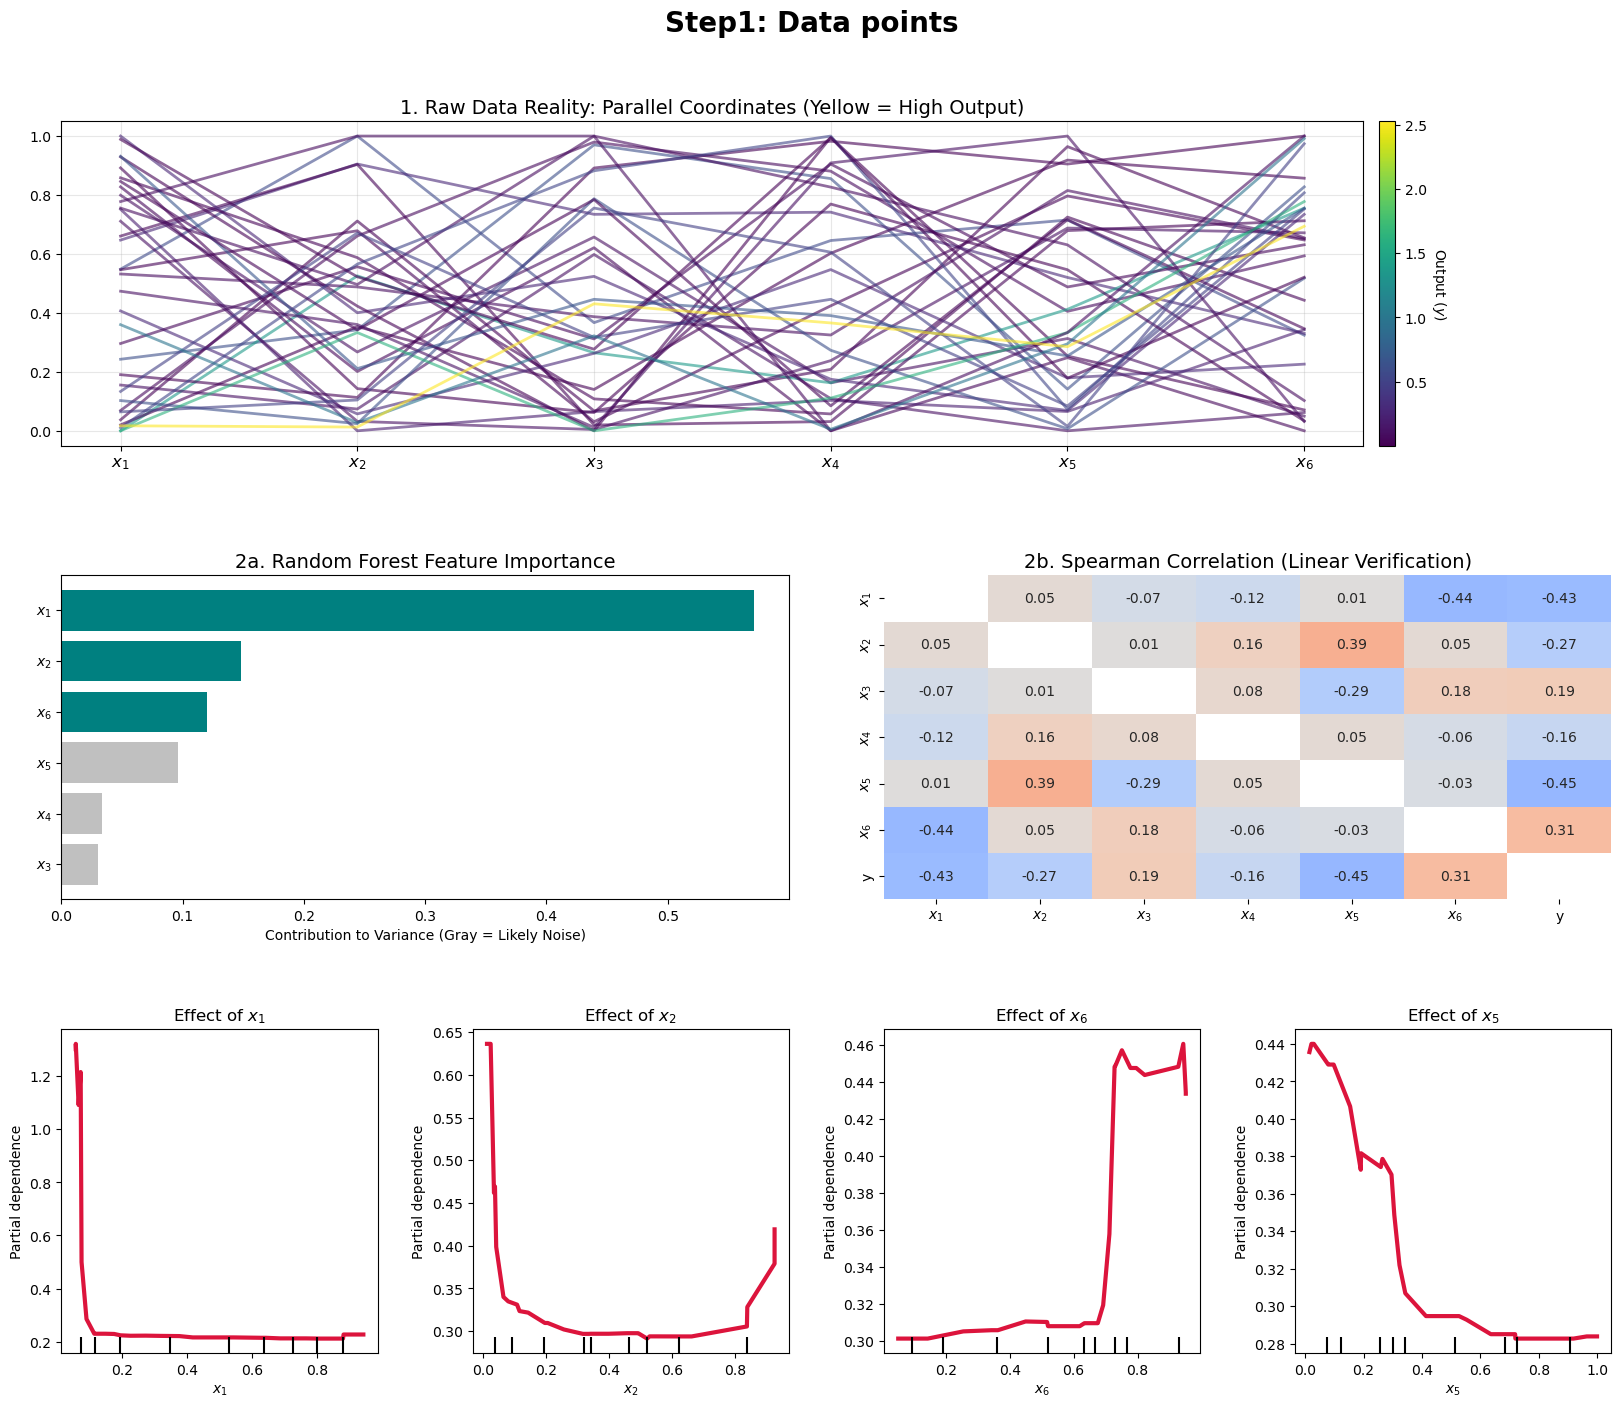

In [4]:
plot_6D_blackbox_analysis(X_train_raw, y_train_raw, "Step1: Data points", f"""
DATA SUMMARY
{'='*30}
Points: {len(X_train_raw)}
Input shape: {X_train_raw.shape}
Output shape: {y_train_raw.shape}

CURRENT BEST
{'='*30}
Current best: {np.max(y_train_raw)}
At input: {X_train_raw[np.argmax(y_train_raw)]}
""")

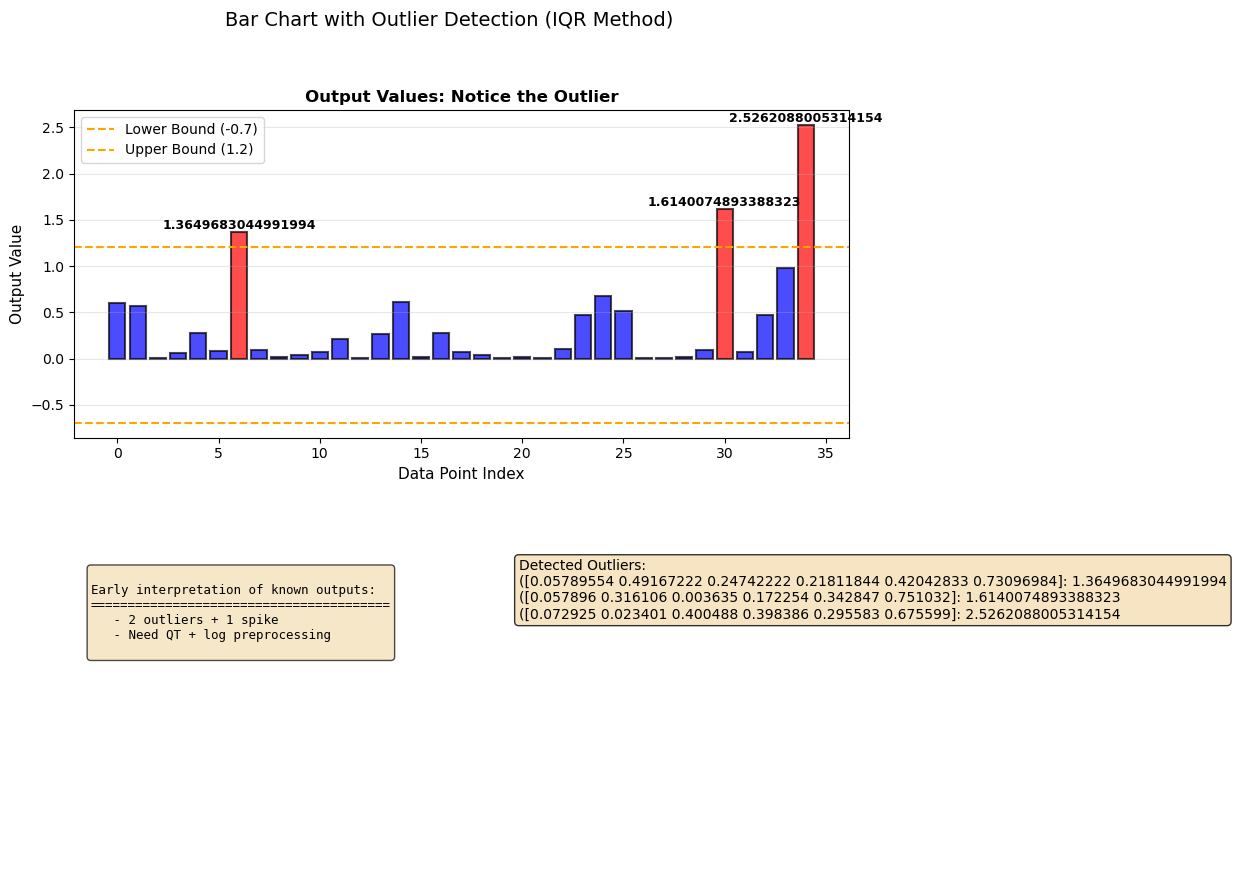

In [5]:
plot_output_outliers(X_train_raw, y_train_raw, "Bar Chart with Outlier Detection (IQR Method)", f"""
Early interpretation of known outputs:
{'='*40}
   - 2 outliers + 1 spike
   - Need QT + log preprocessing
""")

# 2. Preprocessing

Output has outlier spikes. Using QuantileTransformer + log10 shift.

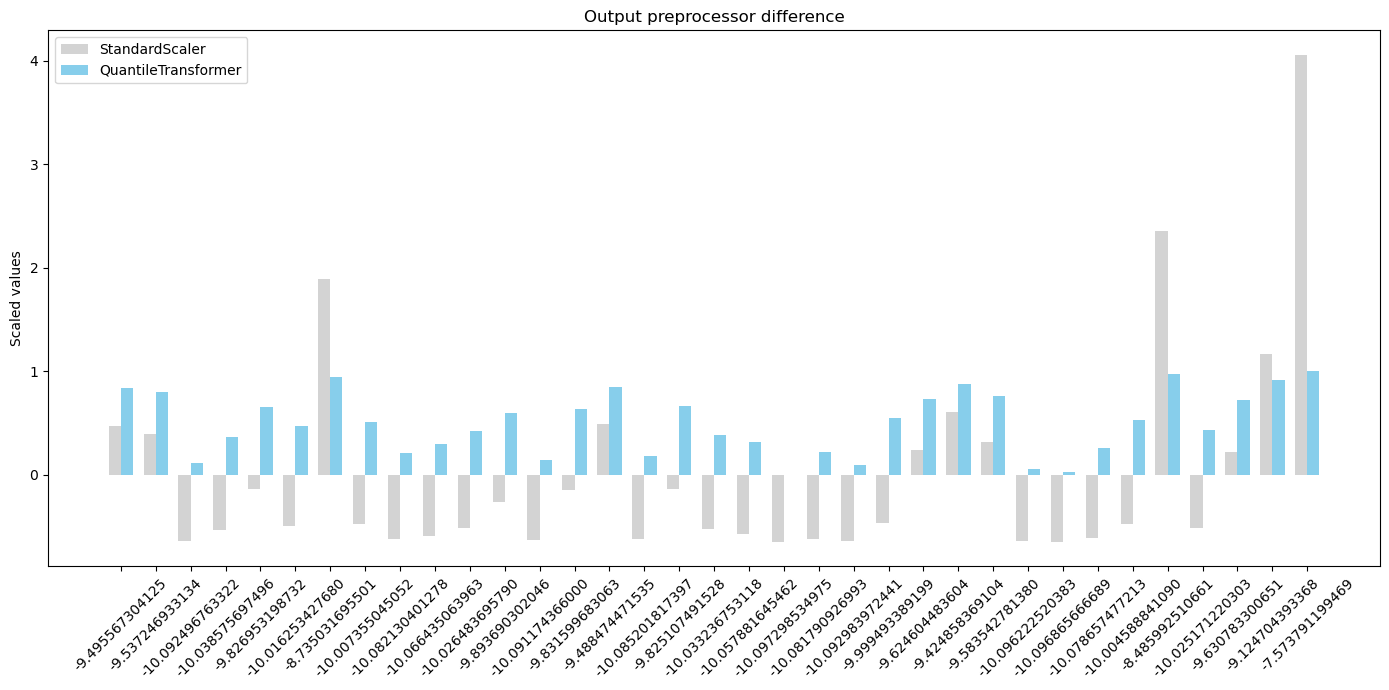

Total points: 35
QT range: [0.0, 1.0]

Log shift constant: 1.00
All 35 points included in log space
log10(y_shifted) range: [0.0023, 0.5476]


In [6]:
scaler_X = MinMaxScaler()
X_train = scaler_X.fit_transform(X_train_raw)

from sklearn.preprocessing import StandardScaler
scaler_ss = StandardScaler()
y_ss = scaler_ss.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

scaler_qt = QuantileTransformer(n_quantiles=len(y_train_raw)-1, output_distribution='uniform')
y_qt = scaler_qt.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

plot_bar_diff(y_train_raw, y_ss, y_qt, 'StandardScaler', 'QuantileTransformer',
              'Scaled values', 'Output preprocessor difference')

print(f"Total points: {len(X_train)}")
print(f"QT range: [{y_qt.min():.1f}, {y_qt.max():.1f}]")

# Log transform: shift by abs(min)+1 guarantees all values positive (min shifted = 1.0)
log_shift_constant = abs(y_train_raw.min()) + 1.0
y_train_raw_shifted = y_train_raw + log_shift_constant
X_train_pos = X_train              # all points (no masking needed)
y_log_pos = np.log10(y_train_raw_shifted)

print(f"\nLog shift constant: {log_shift_constant:.2f}")
print(f"All {len(y_train_raw)} points included in log space")
print(f"log10(y_shifted) range: [{y_log_pos.min():.4f}, {y_log_pos.max():.4f}]")

# 3. Build probabilistic Models (2-GP ensemble)

- **gp_qt**: GP on QuantileTransformer output (all points)
- **gp_log**: GP on log10 output (positive points)

In [7]:
n_dims = 6

# Noise detection pass — weak prior (GammaPrior(1, 0.1), mean=10) allows length scales to
# diverge if the data supports it. The default GammaPrior(3,6) (mean=0.5) suppresses all
# ls below ~2.0, making absolute/relative thresholds fail to distinguish noise dims.
# This is the same approach used in Fn8. A short 200-step run is enough for detection.
weak_ls_prior = gpytorch.priors.GammaPrior(1.0, 0.1)  # mean=10, heavy tail
model_detect, likelihood_detect, _ = fit_gpytorch_model(
    X_train, y_qt, n_dims=n_dims, noise=0.01, n_steps=200, lr=0.1,
    ls_prior=weak_ls_prior)

ls_detect = model_detect.covar_module.base_kernel.lengthscale.detach().numpy().ravel()
ls_mean_d = ls_detect.mean()
ls_std_d = ls_detect.std()
noise_threshold_detect = ls_mean_d + 2 * ls_std_d
noise_dims_detect = np.where(ls_detect > noise_threshold_detect)[0].tolist()
noise_dim_idx = noise_dims_detect[0] if len(noise_dims_detect) >= 1 else 2  # fallback: x3
detection_method = 'weak-prior ARD' if len(noise_dims_detect) >= 1 else 'fallback (Week 5 evidence)'

print(f"Detection GP ls: {ls_detect}")
print(f"mean={ls_mean_d:.4f}, std={ls_std_d:.4f}, threshold={noise_threshold_detect:.4f}")
print(f"Noise dim: x{noise_dim_idx+1} (ls={ls_detect[noise_dim_idx]:.4f}, by {detection_method})")

# Main GPs — standard prior (GammaPrior(3,6)) for acquisition and visualization.
model_qt, likelihood_qt, losses_qt = fit_gpytorch_model(
    X_train, y_qt, n_dims=n_dims, noise=0.01, n_steps=300, lr=0.1)

model_log, likelihood_log, losses_log = fit_gpytorch_model(
    X_train, y_log_pos, n_dims=n_dims, noise=0.01, n_steps=400, lr=0.1)

conv_qt, info_qt = gp_converged_gpytorch(losses_qt)
conv_log, info_log = gp_converged_gpytorch(losses_log)
print(f"\nGP(QT):  final_loss={info_qt['final_loss']:.4f}, loss_drop={info_qt['loss_drop']:.4f}, converged={conv_qt}")
print(f"GP(log): final_loss={info_log['final_loss']:.4f}, loss_drop={info_log['loss_drop']:.4f}, converged={conv_log}")

# Feature importance from main GPs (for visualization)
for name, mdl in [('GP(QT)', model_qt), ('GP(log)', model_log)]:
    ls = mdl.covar_module.base_kernel.lengthscale.detach().numpy().ravel()
    imp = 1.0 / ls
    imp_norm = imp / imp.sum() * 100
    print(f"\n{name} length scales: {ls}")
    sorted_dims = np.argsort(ls)
    for i in sorted_dims:
        role = 'IMPORTANT' if ls[i] < 1.0 else ('moderate' if ls[i] < 5.0 else 'noise')
        print(f"  x{i+1}: ls={ls[i]:.4f}, importance={imp_norm[i]:.1f}%, {role}")

# Determine plot/slider dims from main gp_qt length scales
ls_qt = model_qt.covar_module.base_kernel.lengthscale.detach().numpy().ravel()
sorted_dims_qt = np.argsort(ls_qt)
most_important = sorted_dims_qt[:2]
least_important = sorted_dims_qt[2:]
dim_a, dim_b = most_important[0], most_important[1]
slider_dims = least_important
print(f"\nPlotting dims: x{dim_a+1}, x{dim_b+1}")
print(f"Slider dims: {['x'+str(d+1) for d in slider_dims]}")

# Create prediction grid (for visualization)
n_grid_2d = 40
x_plot_1 = np.linspace(0, 1, n_grid_2d)
x_plot_2 = np.linspace(0, 1, n_grid_2d)
X1_plot, X2_plot = np.meshgrid(x_plot_1, x_plot_2)

X_train_neg = np.empty((0, X_train.shape[1]))

Detection GP ls: [1.611664   0.7844778  2.30315096 0.47238759 0.41433793 0.46801575]
mean=1.0090, std=0.7098, threshold=2.4286
Noise dim: x3 (ls=2.3032, by fallback (Week 5 evidence))

GP(QT):  final_loss=0.0241, loss_drop=0.5953, converged=True
GP(log): final_loss=-0.7735, loss_drop=1.3198, converged=True

GP(QT) length scales: [0.67754491 0.55155691 0.65443805 0.38256222 0.32473832 0.49007862]
  x5: ls=0.3247, importance=24.5%, IMPORTANT
  x4: ls=0.3826, importance=20.8%, IMPORTANT
  x6: ls=0.4901, importance=16.3%, IMPORTANT
  x2: ls=0.5516, importance=14.4%, IMPORTANT
  x3: ls=0.6544, importance=12.2%, IMPORTANT
  x1: ls=0.6775, importance=11.8%, IMPORTANT

GP(log) length scales: [0.64597887 0.57481717 0.7809389  0.48383234 0.24935128 0.35263597]
  x5: ls=0.2494, importance=29.7%, IMPORTANT
  x6: ls=0.3526, importance=21.0%, IMPORTANT
  x4: ls=0.4838, importance=15.3%, IMPORTANT
  x2: ls=0.5748, importance=12.9%, IMPORTANT
  x1: ls=0.6460, importance=11.5%, IMPORTANT
  x3: ls=0.780

### GP Slices

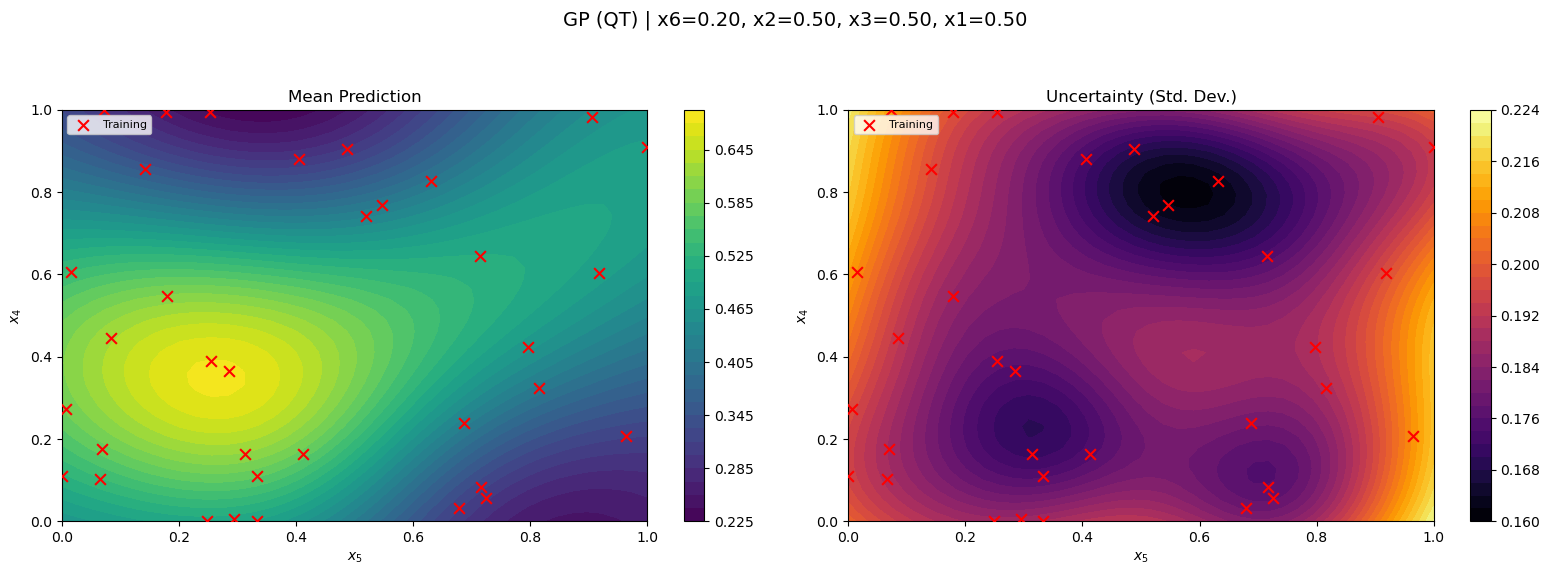

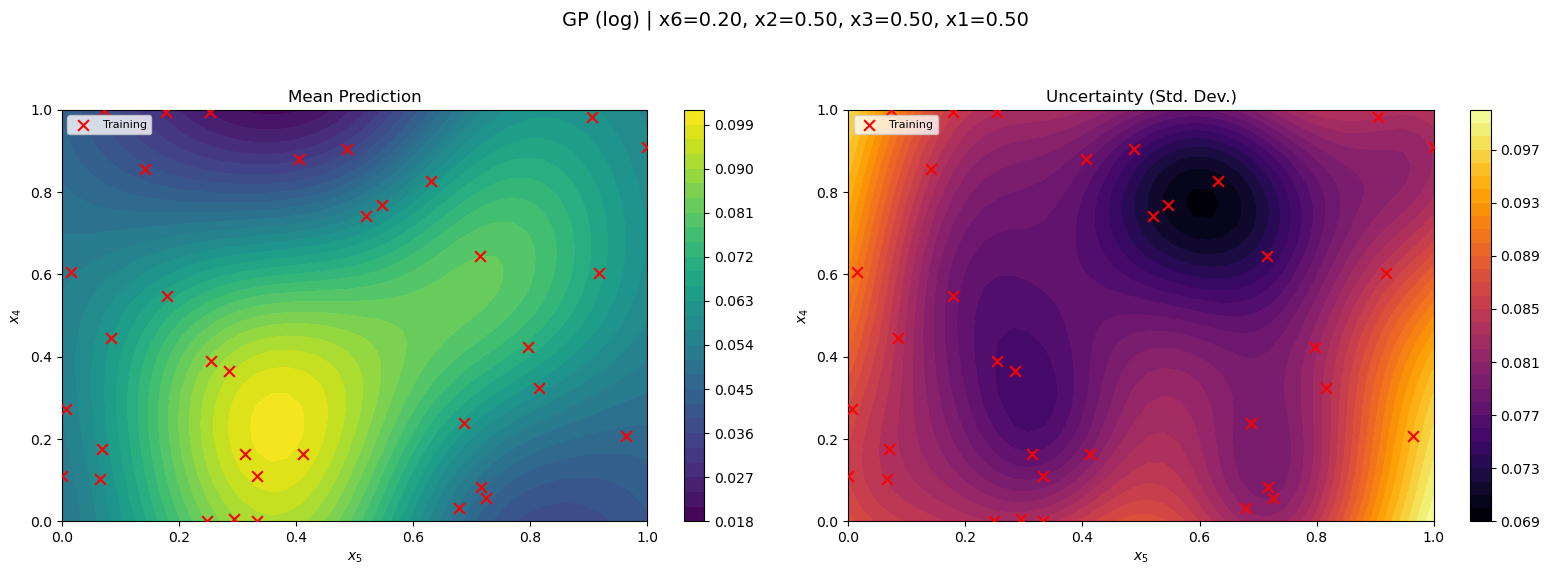

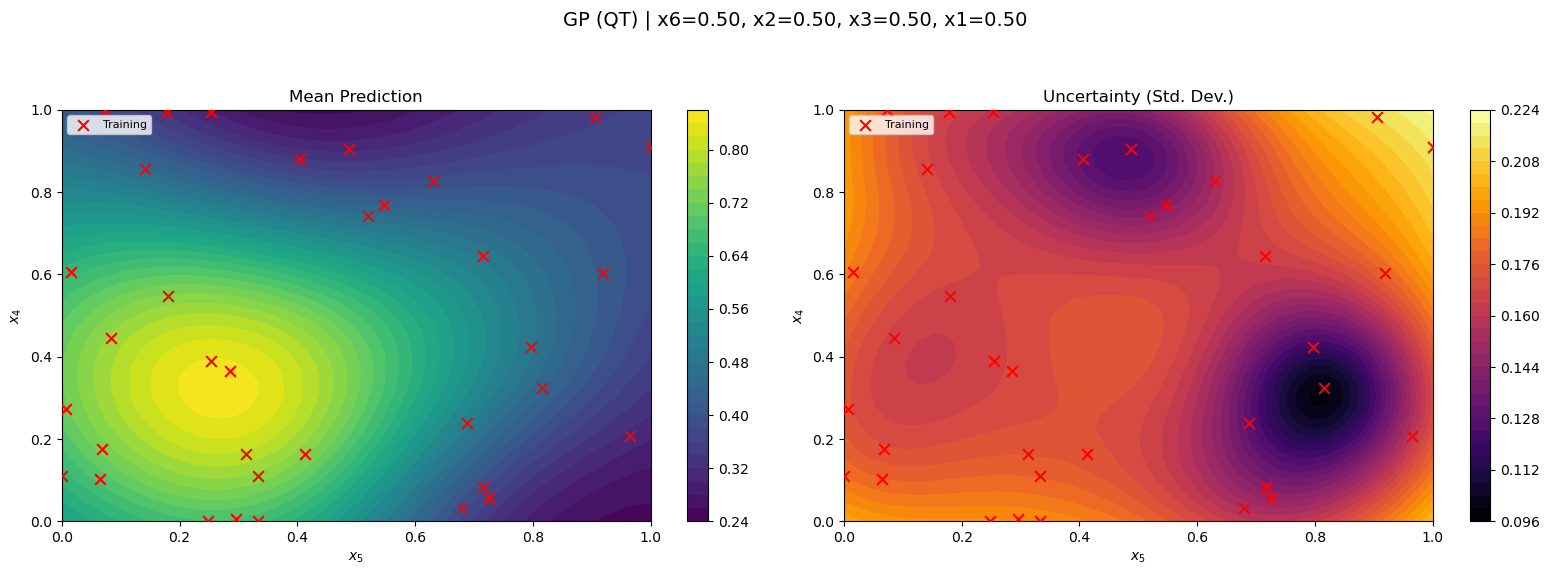

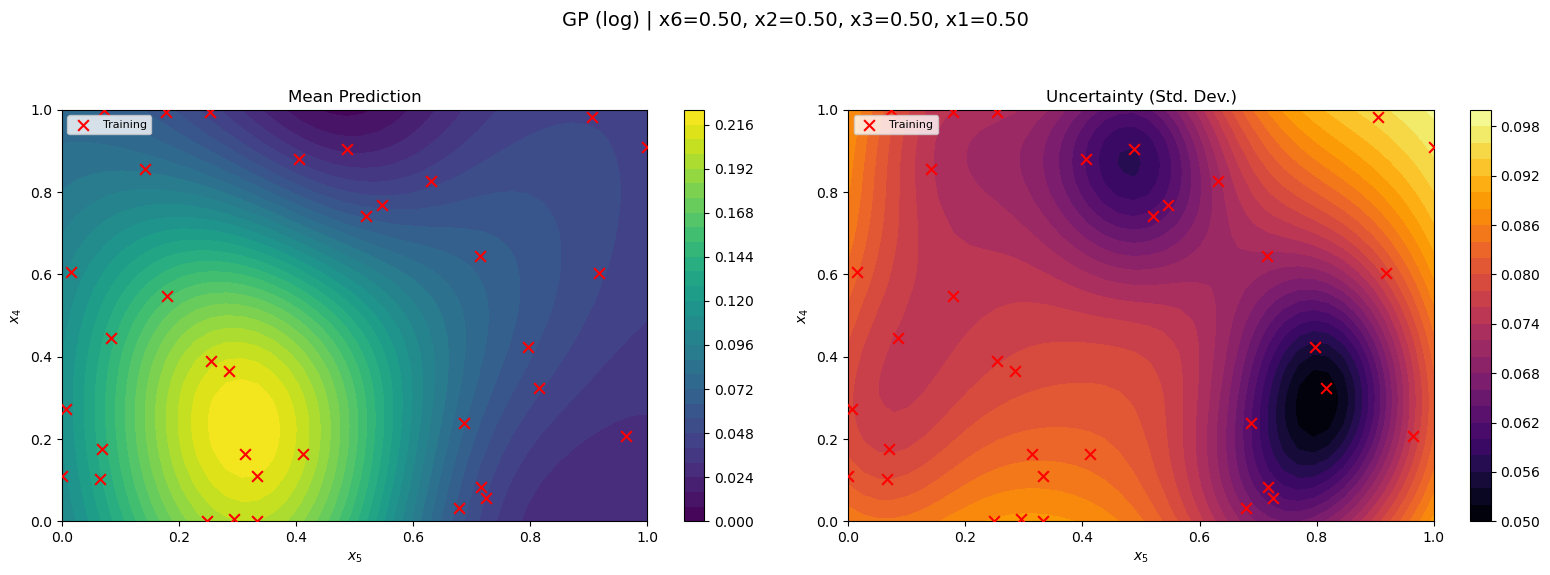

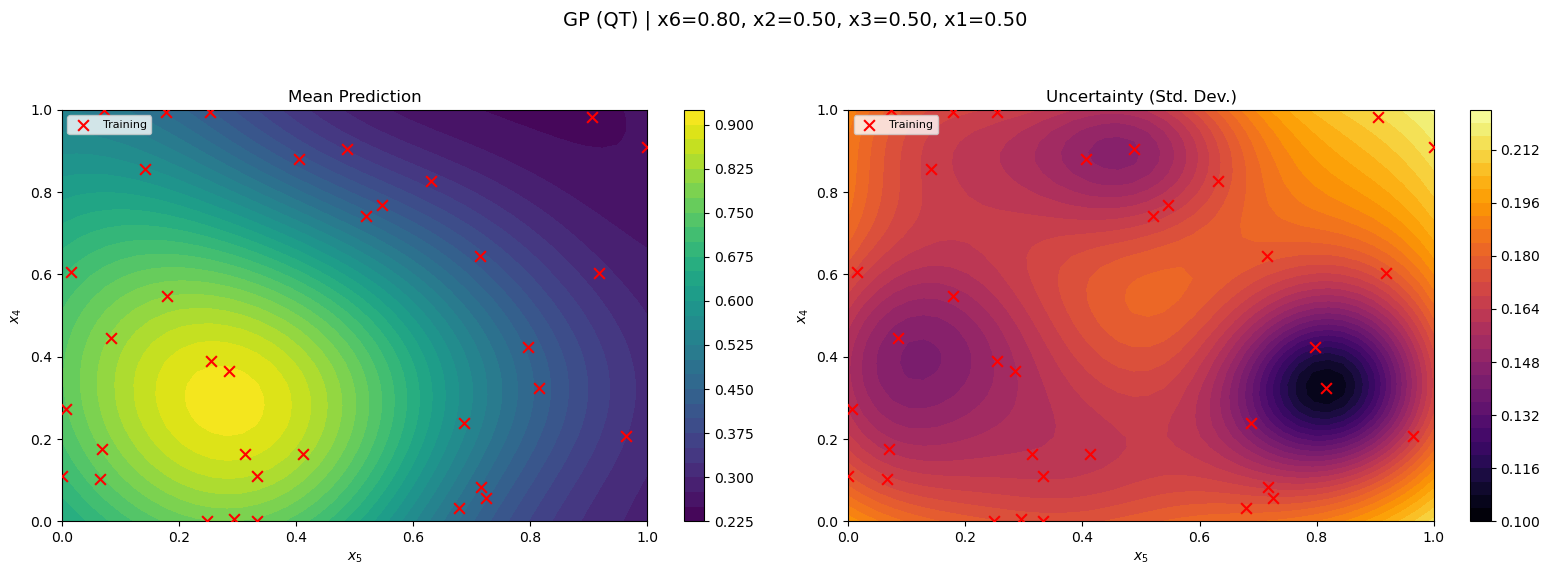

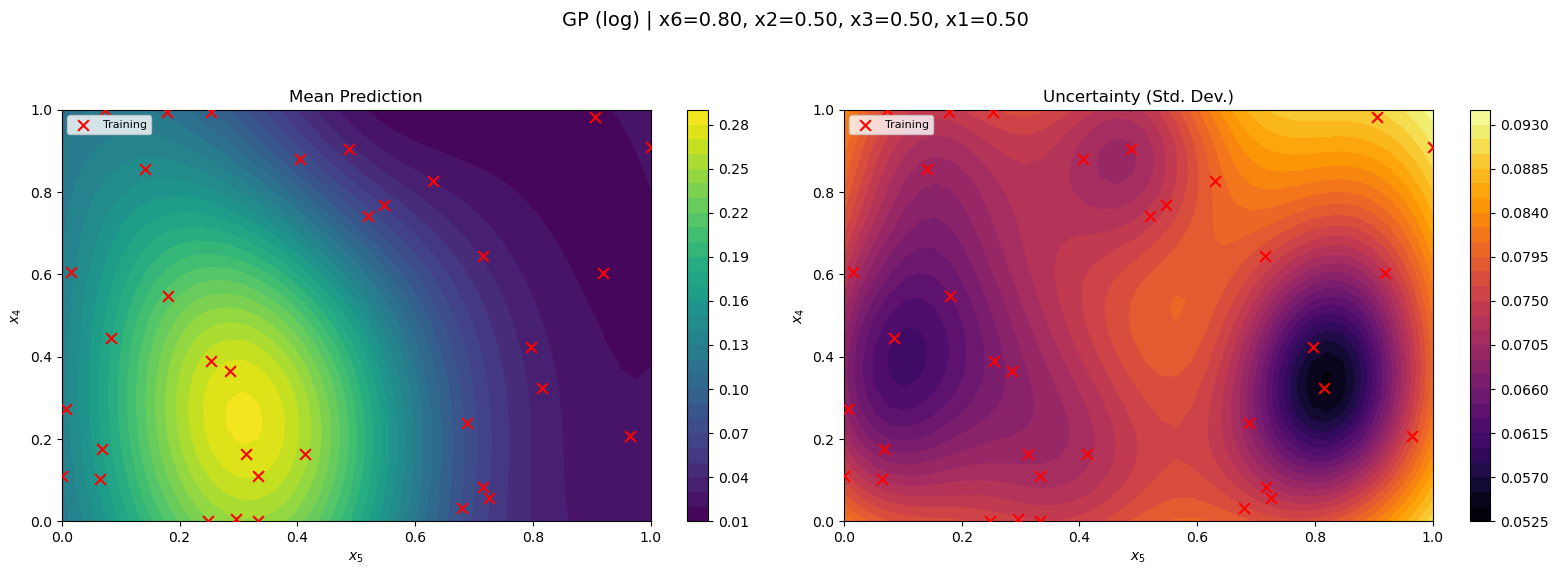

In [8]:
def plot_gp_slices(**kwargs):
    grid_nd = np.zeros((n_grid_2d * n_grid_2d, n_dims))
    grid_nd[:, dim_a] = X1_plot.ravel()
    grid_nd[:, dim_b] = X2_plot.ravel()
    for d in slider_dims:
        grid_nd[:, d] = kwargs[f'x{d+1}']

    fixed_parts = [f'x{d+1}={kwargs[f"x{d+1}"]:.2f}' for d in slider_dims]
    fixed_info = ', '.join(fixed_parts)

    mu_qt, sigma_qt = gp_predict(model_qt, likelihood_qt, grid_nd)
    plot_nd_mean_uncertainty_slice(
        X_train, X1_plot, X2_plot,
        mu_qt.reshape(n_grid_2d, n_grid_2d),
        sigma_qt.reshape(n_grid_2d, n_grid_2d),
        dim1_idx=dim_a, dim2_idx=dim_b,
        title_prefix='GP (QT)', fixed_info=fixed_info
    )

    mu_log, sigma_log = gp_predict(model_log, likelihood_log, grid_nd)
    plot_nd_mean_uncertainty_slice(
        X_train, X1_plot, X2_plot,
        mu_log.reshape(n_grid_2d, n_grid_2d),
        sigma_log.reshape(n_grid_2d, n_grid_2d),
        dim1_idx=dim_a, dim2_idx=dim_b,
        title_prefix='GP (log)', fixed_info=fixed_info
    )

for v in [0.2, 0.5, 0.8]:
    kws = {f'x{d+1}': (v if d == slider_dims[0] else 0.5) for d in slider_dims}
    plot_gp_slices(**kws)

# 4. SVM Analysis


=== Support Vectors: 32 / 35 training points ===
 Idx         Label        x1        x2        x3        x4        x5        x6         y_raw
   2           not    0.0908    0.6615    0.0659    0.2586    0.9635    0.6403      0.007503
   3           not    0.1189    0.6151    0.9058    0.8553    0.4136    0.5852      0.061424
   5           not    0.7649    0.2559    0.6091    0.2181    0.3229    0.0958      0.083747
   7           not    0.1953    0.0792    0.5546    0.1706    0.0149    0.1070      0.092645
   8           not    0.6423    0.8369    0.0218    0.1015    0.6831    0.6924      0.017870
   9           not    0.7899    0.1955    0.5756    0.0737    0.2590    0.0511      0.033565
  10           not    0.5285    0.4574    0.3601    0.3620    0.8169    0.6375      0.073516
  12           not    0.0757    0.3345    0.1327    0.6083    0.9184    0.8223      0.008826
  15           not    0.8171    0.5482    0.1033    0.1244    0.7282    0.4497      0.014798
  17           not  

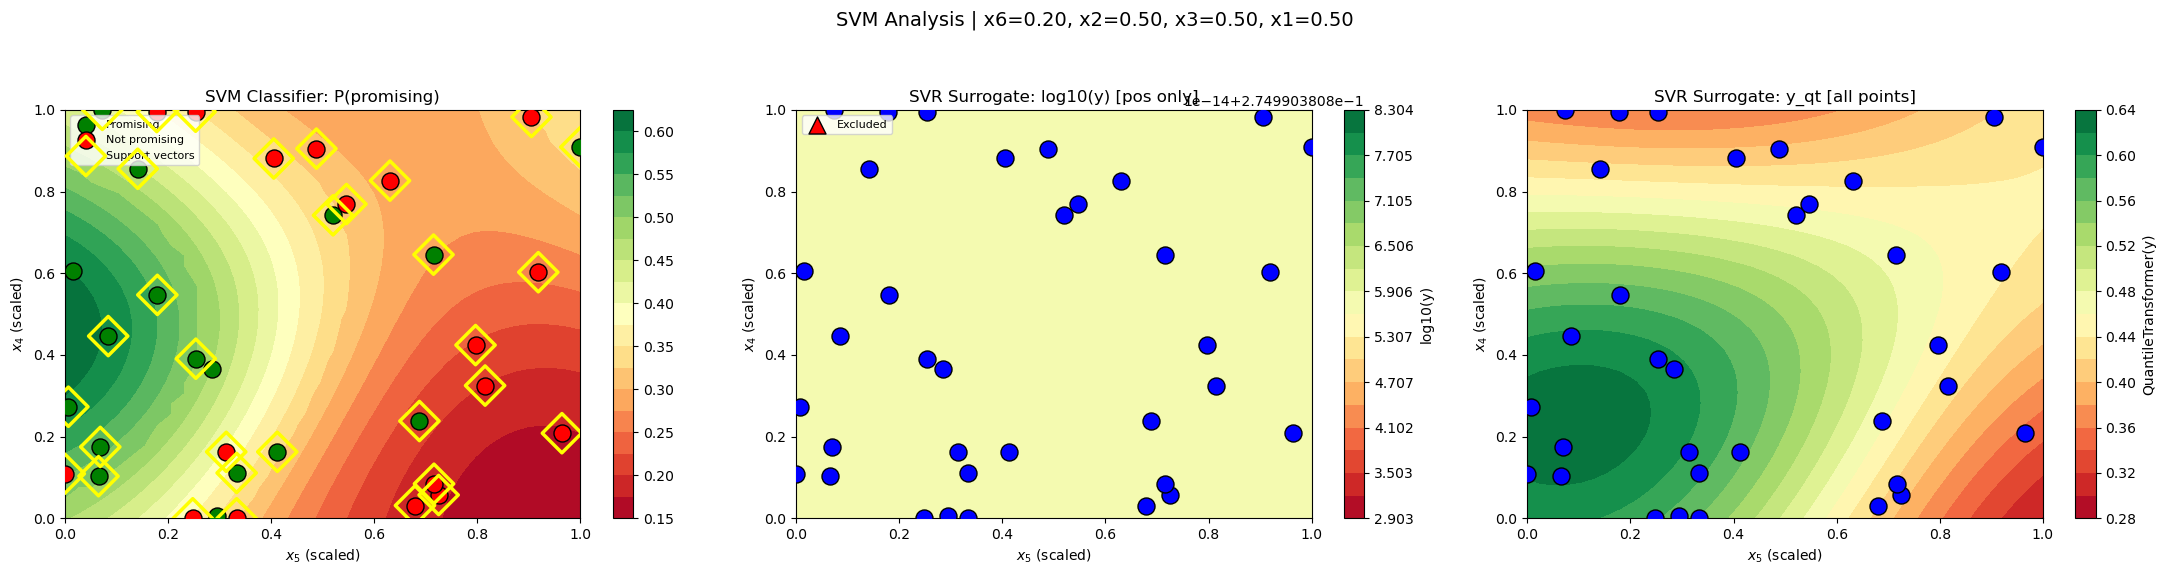

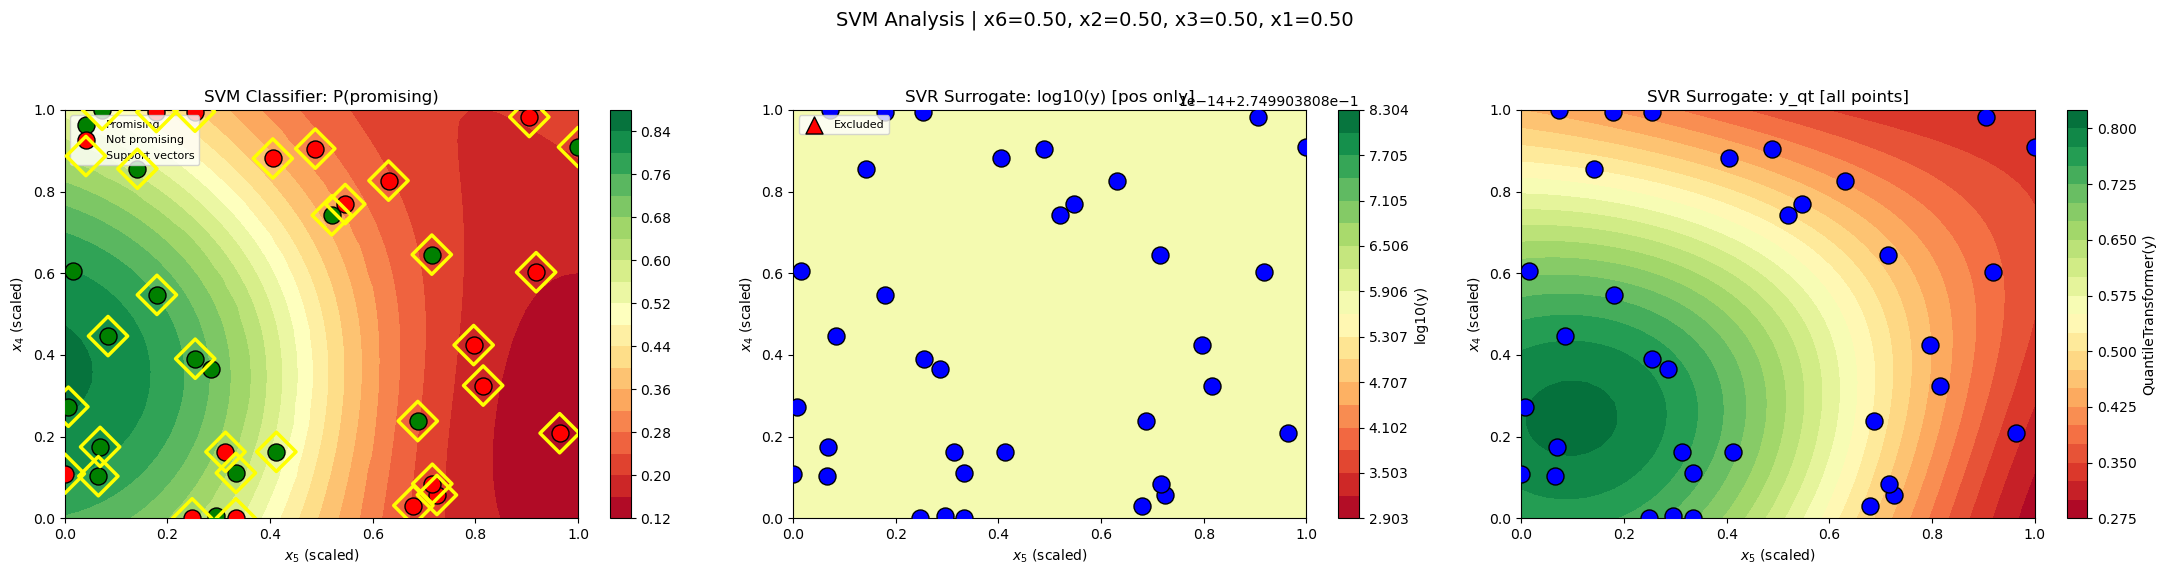

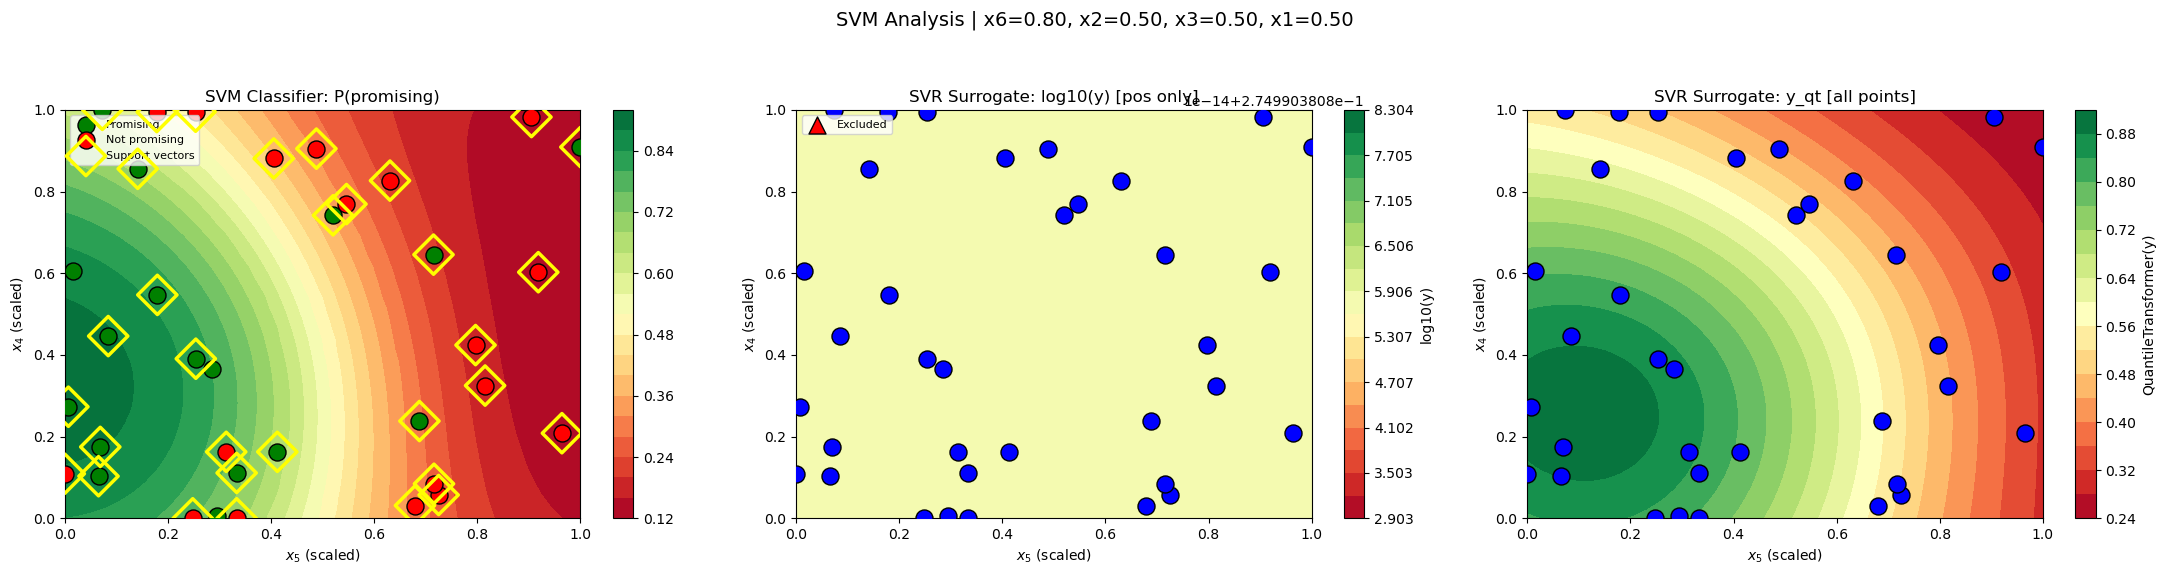

In [9]:
# SVM Classifier
# C=1 (soft margin): prevents decision boundary collapse in the 6D, 35-pt regime.
# gamma=2.0: between 'auto' (too broad → flat P) and 'scale' (too local → boundary collapse).
svm_labels = (y_log_pos > np.median(y_log_pos)).astype(int)

svm_clf = SVC(kernel='rbf', C=1, gamma=2.0, probability=True)
svm_clf.fit(X_train, svm_labels)

# --- Support Vector Analysis ---
sv_indices = svm_clf.support_
support_vec_mask = np.zeros(len(X_train), dtype=bool)
support_vec_mask[sv_indices] = True

X_sv_orig = scaler_X.inverse_transform(X_train[sv_indices])
y_sv_raw  = y_train_raw[sv_indices]
sv_labels_vals = svm_labels[sv_indices]

print(f"\n=== Support Vectors: {len(sv_indices)} / {len(X_train)} training points ===")
print(f"{'Idx':>4}  {'Label':>12}  {'x1':>8}  {'x2':>8}  {'x3':>8}  {'x4':>8}  {'x5':>8}  {'x6':>8}  {'y_raw':>12}")
for ti, x_o, y_o, lbl in zip(sv_indices, X_sv_orig, y_sv_raw, sv_labels_vals):
    coords = "  ".join(f"{v:>8.4f}" for v in x_o)
    print(f"{ti:>4}  {'promising' if lbl else 'not':>12}  {coords}  {y_o:>12.6f}")

# SVR surrogates
svr_log = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.5)
svr_log.fit(X_train_pos, y_log_pos)

svr_qt = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_qt.fit(X_train, y_qt)

print(f"SVM labels: {svm_labels.sum()} promising, {(1-svm_labels).sum()} not promising")

# SVM slices
def plot_svm_slices(**kwargs):
    grid_nd = np.zeros((n_grid_2d * n_grid_2d, n_dims))
    grid_nd[:, dim_a] = X1_plot.ravel()
    grid_nd[:, dim_b] = X2_plot.ravel()
    for d in slider_dims:
        grid_nd[:, d] = kwargs[f'x{d+1}']

    fixed_parts = [f'x{d+1}={kwargs[f"x{d+1}"]:.2f}' for d in slider_dims]
    fixed_info = ', '.join(fixed_parts)

    svm_proba_slice = svm_clf.predict_proba(grid_nd)[:, 1]
    mu_svr_log_slice = svr_log.predict(grid_nd)
    mu_svr_qt_slice = svr_qt.predict(grid_nd)

    plot_nd_svm_analysis_slice(
        X1_plot, X2_plot,
        svm_proba_slice.reshape(n_grid_2d, n_grid_2d),
        mu_svr_log_slice.reshape(n_grid_2d, n_grid_2d),
        mu_svr_qt_slice.reshape(n_grid_2d, n_grid_2d),
        X_train, X_train_pos, X_train_neg, svm_labels,
        dim1_idx=dim_a, dim2_idx=dim_b, fixed_info=fixed_info,
        support_vec_mask=support_vec_mask
    )

for v in [0.2, 0.5, 0.8]:
    kws = {f'x{d+1}': (v if d == slider_dims[0] else 0.5) for d in slider_dims}
    plot_svm_slices(**kws)

# 5. Acquisition Function (SVM-constrained UCB Ensemble)

50,000 LHS candidates in [0,1]^6 for adequate coverage of the 6D space.

Noise dim: x3 (index 2), fixed at training mean = 0.4309
Active dims for LHS: ['x1', 'x2', 'x4', 'x5', 'x6']
kappa = 3.8462 (week 6/13)


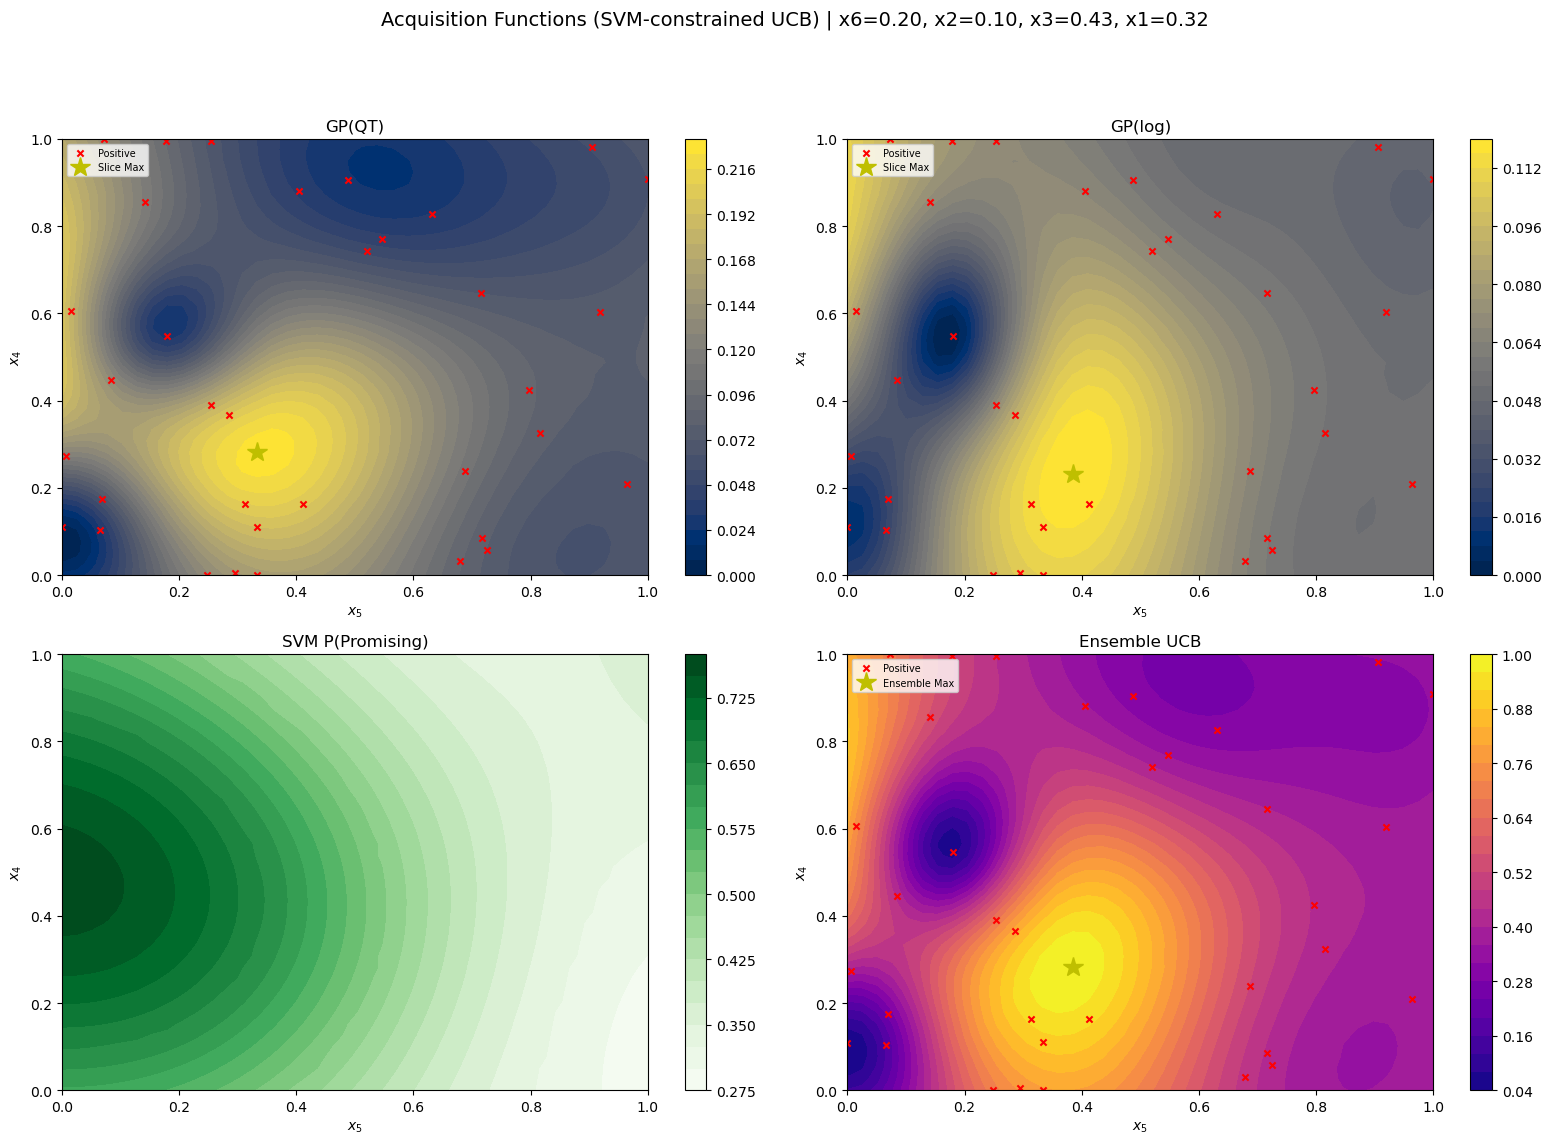

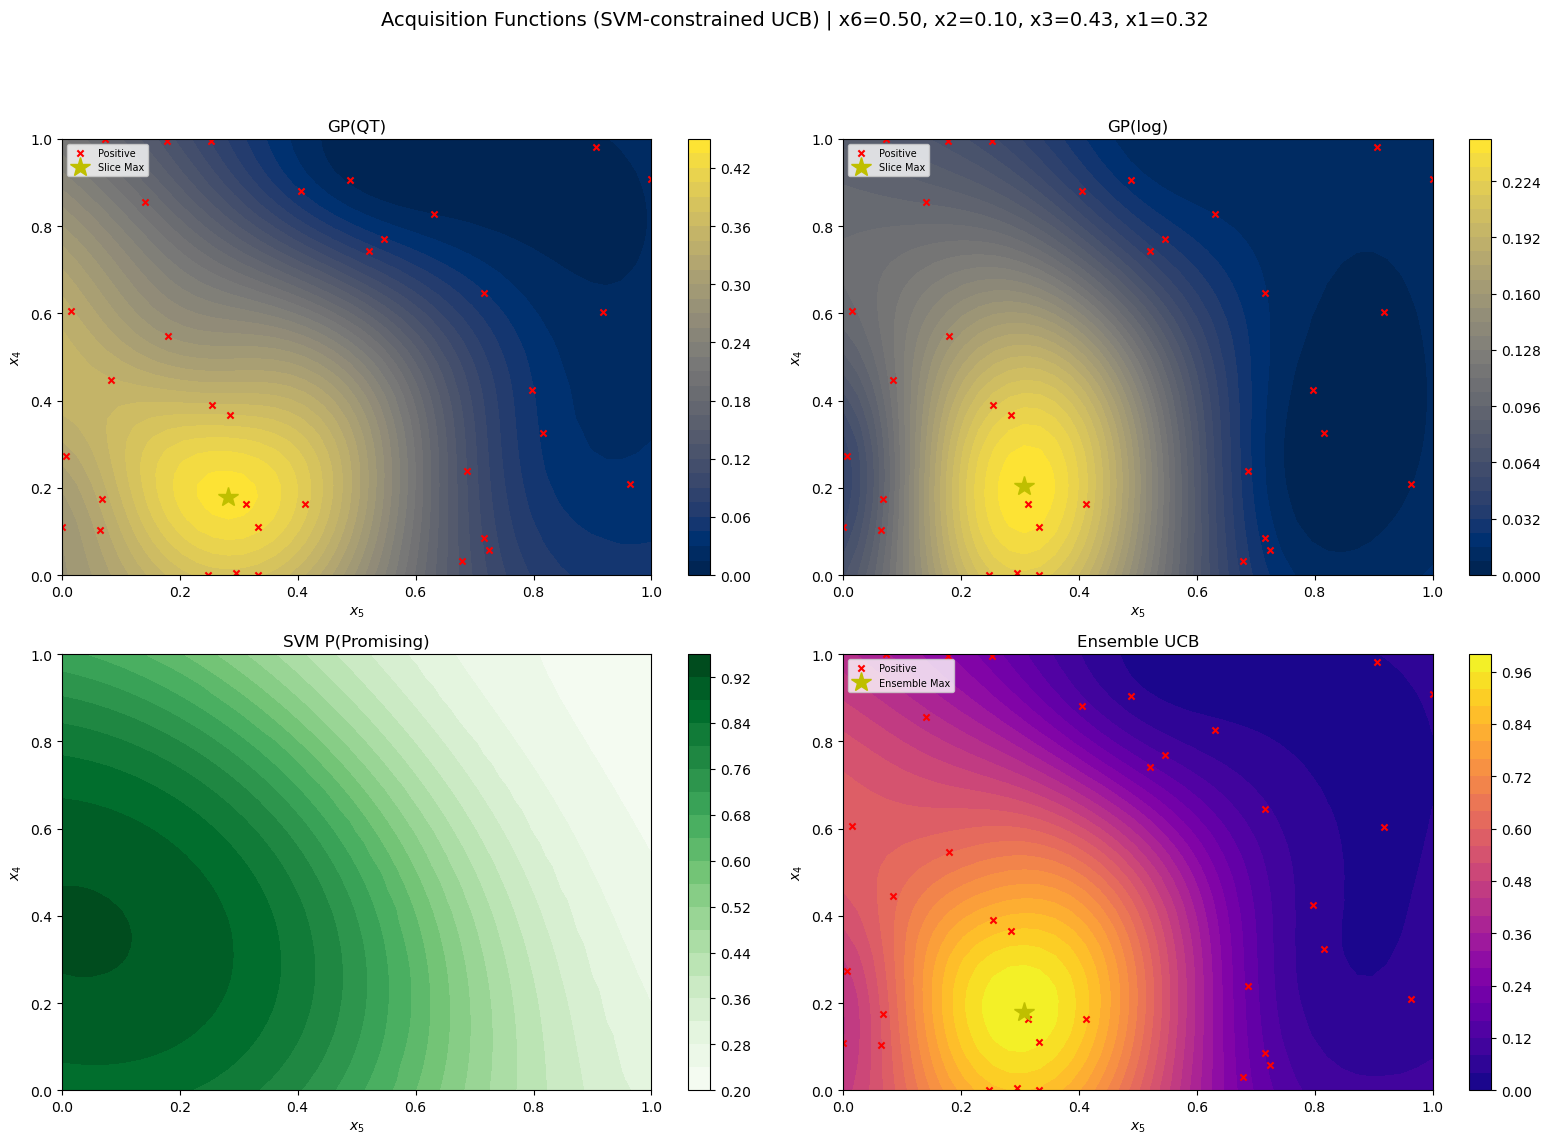

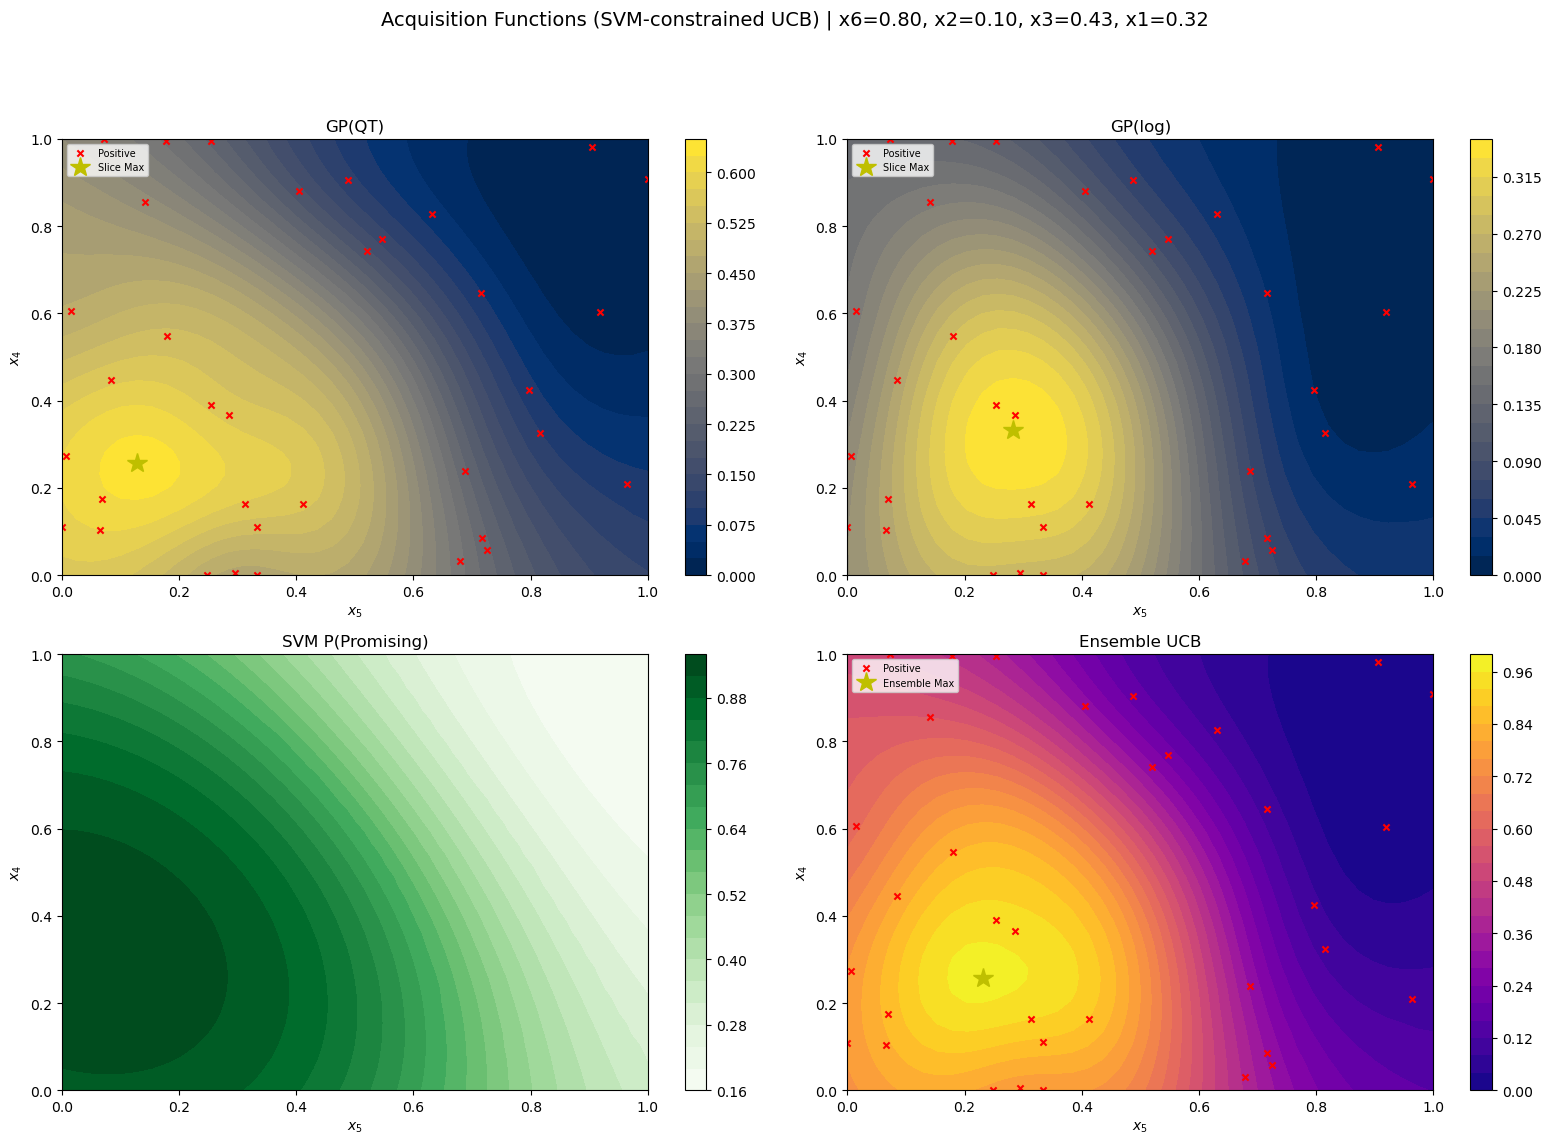

RECOMMENDED NEXT POINT (Ensemble of 2 GPs, 50K LHS in 5D active space)
  Input (original space): [0.339751 0.104266 0.400488 0.234337 0.254864 0.687915]
  SVM P(promising):       0.925

Individual surrogate suggestions:
    GP (y_qt)           : [0.342243 0.182091 0.400488 0.307198 0.210364 0.696186] (SVM P=0.936)
    GP (y_log)          : [0.257538 0.065539 0.400488 0.182367 0.297716 0.649811] (SVM P=0.900)

Sanity check - is this a corner?
  x1 = 0.3186 
  x2 = 0.1013 
  x3 = 0.4309 (noise dim, fixed at training mean)
  x4 = 0.1811 
  x5 = 0.2439 
  x6 = 0.7076 

Current best: [0.072925 0.023401 0.400488 0.398386 0.295583 0.675599] (y = 2.5262088005314154)

  SVM coverage: 35.9% promising (fail-safe threshold: 5%)
  SVM effective weights: SVM P(promising)

SUBMISSION: 0.339751-0.104266-0.400488-0.234337-0.254864-0.687915


In [10]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    return mu + kappa * sigma

def constrained_ucb(ucb_vals, svm_proba):
    ucb_shifted = ucb_vals - ucb_vals.min() + 1e-6
    return ucb_shifted * svm_proba

def normalize_01(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)

# x3 (noise_dim_idx) identified dynamically in GP fitting cell (ls > 100.0).
# Active subspace LHS: search over 5D, fix noise dim at training mean.
active_dims_acq = [d for d in range(n_dims) if d != noise_dim_idx]
n_active_acq = len(active_dims_acq)
x_noise_fixed = X_train[:, noise_dim_idx].mean()
print(f"Noise dim: x{noise_dim_idx+1} (index {noise_dim_idx}), fixed at training mean = {x_noise_fixed:.4f}")
print(f"Active dims for LHS: {['x'+str(d+1) for d in active_dims_acq]}")

# Generate LHS in active subspace (50K for coverage)
sampler = LatinHypercube(d=n_active_acq, seed=42)
X_cand_active = sampler.random(n=50_000)

# Reconstruct full 6D candidates with noise dim fixed
X_candidates = np.zeros((50_000, n_dims))
for j, orig_dim in enumerate(active_dims_acq):
    X_candidates[:, orig_dim] = X_cand_active[:, j]
X_candidates[:, noise_dim_idx] = x_noise_fixed

# Budget-aware kappa: linear decay from 5.0 (week 1) to 2.0 (week 13)
WEEK = 6
kappa = 5.0 - ((WEEK - 1) / 13) * 3.0
print(f"kappa = {kappa:.4f} (week {WEEK}/13)")

# GP predictions on candidates (full 6D GPs, noise dim fixed so it contributes nothing)
mu_gp_qt, sigma_gp_qt = gp_predict(model_qt, likelihood_qt, X_candidates)
mu_gp_log, sigma_gp_log = gp_predict(model_log, likelihood_log, X_candidates)

# SVM probability
svm_proba = svm_clf.predict_proba(X_candidates)[:, 1]

if (svm_proba > 0.5).mean() < 0.05:
    print("WARNING: SVM classified <5% of candidates as promising — applying fail-safe (uniform weights).")
    svm_proba_effective = np.ones_like(svm_proba)
else:
    svm_proba_effective = svm_proba

# UCB scores
ucb_gp_qt = upper_confidence_bound(mu_gp_qt, sigma_gp_qt, kappa=kappa)
ucb_gp_log = upper_confidence_bound(mu_gp_log, sigma_gp_log, kappa=kappa)

# Constrained UCBs
ucb_c_gp_qt = constrained_ucb(ucb_gp_qt, svm_proba_effective)
ucb_c_gp_log = constrained_ucb(ucb_gp_log, svm_proba_effective)

# Ensemble
ensemble_ucb = (normalize_01(ucb_c_gp_qt) + normalize_01(ucb_c_gp_log)) / 2.0

best_ensemble_idx = np.argmax(ensemble_ucb)
x_next_norm = X_candidates[best_ensemble_idx]  # full 6D, noise dim fixed
x_next_orig = scaler_X.inverse_transform([x_next_norm])[0]

# Per-surrogate bests
surrogates = {'GP (y_qt)': ucb_c_gp_qt, 'GP (y_log)': ucb_c_gp_log}
best_points = {}
for name, ucb_vals in surrogates.items():
    idx = np.argmax(ucb_vals)
    best_points[name] = {
        'idx': idx, 'norm': X_candidates[idx],
        'orig': scaler_X.inverse_transform([X_candidates[idx]])[0],
        'svm_p': svm_proba[idx]
    }

# Acquisition slices
def plot_acq_slices(**kwargs):
    grid_nd = np.zeros((n_grid_2d * n_grid_2d, n_dims))
    grid_nd[:, dim_a] = X1_plot.ravel()
    grid_nd[:, dim_b] = X2_plot.ravel()
    for d in slider_dims:
        grid_nd[:, d] = kwargs[f'x{d+1}']

    fixed_parts = [f'x{d+1}={kwargs[f"x{d+1}"]:.2f}' for d in slider_dims]
    fixed_info = ', '.join(fixed_parts)

    mu_qt_s, sigma_qt_s = gp_predict(model_qt, likelihood_qt, grid_nd)
    mu_log_s, sigma_log_s = gp_predict(model_log, likelihood_log, grid_nd)
    svm_p_s = svm_clf.predict_proba(grid_nd)[:, 1]

    ucb_qt_s = constrained_ucb(upper_confidence_bound(mu_qt_s, sigma_qt_s, kappa), svm_p_s)
    ucb_log_s = constrained_ucb(upper_confidence_bound(mu_log_s, sigma_log_s, kappa), svm_p_s)
    ens_s = (normalize_01(ucb_qt_s) + normalize_01(ucb_log_s)) / 2.0

    shape = (n_grid_2d, n_grid_2d)
    plot_nd_acquisition_comparison_slice(
        X1_plot, X2_plot,
        {'GP(QT)': ucb_qt_s.reshape(shape), 'GP(log)': ucb_log_s.reshape(shape)},
        svm_p_s.reshape(shape), ens_s.reshape(shape),
        X_train_pos, X_train_neg,
        dim1_idx=dim_a, dim2_idx=dim_b, fixed_info=fixed_info
    )

for v in [0.2, 0.5, 0.8]:
    kws = {f'x{d+1}': (v if d == slider_dims[0] else float(x_next_norm[d])) for d in slider_dims}
    plot_acq_slices(**kws)

# Summary
print(f"{'='*80}")
print(f"RECOMMENDED NEXT POINT (Ensemble of 2 GPs, 50K LHS in {n_active_acq}D active space)")
print(f"{'='*80}")
print(f"  Input (original space): {np.array_str(x_next_orig, precision=6)}")
print(f"  SVM P(promising):       {svm_proba[best_ensemble_idx]:.3f}")

print(f"\nIndividual surrogate suggestions:")
for name, bp in best_points.items():
    print(f"    {name:20s}: {np.array_str(bp['orig'], precision=6)} (SVM P={bp['svm_p']:.3f})")

print(f"\nSanity check - is this a corner?")
for i in range(n_dims):
    if i == noise_dim_idx:
        print(f"  x{i+1} = {x_next_norm[i]:.4f} (noise dim, fixed at training mean)")
    else:
        at_boundary = x_next_norm[i] < 0.02 or x_next_norm[i] > 0.98
        print(f"  x{i+1} = {x_next_norm[i]:.4f} {'<-- BOUNDARY!' if at_boundary else ''}")

print(f"\nCurrent best: {X_train_raw[np.argmax(y_train_raw)]} (y = {y_train_raw.max()})")
print(f"\n  SVM coverage: {(svm_proba > 0.5).mean()*100:.1f}% promising (fail-safe threshold: 5%)")
print(f"  SVM effective weights: {'uniform (fail-safe)' if (svm_proba > 0.5).mean() < 0.05 else 'SVM P(promising)'}")

# Machine-readable tag for get_submission.py
print(f"\nSUBMISSION: {'-'.join(f'{x:.6f}' for x in x_next_orig)}")